<a href="https://colab.research.google.com/github/panyapornmo68-rgb/Coffee-Quality-Analysis-and-Prediction/blob/main/Coffee_Quality_Analysis_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: Coffee Quality Analysis and Prediction
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:**
- สมาชิกที่ 1: นางสาวปัญญาพร มูลดับ รหัสนักศึกษา 68114540399
- สมาชิกที่ 2: นางสาวรัชรินทร์ เเสงภักดิ์ รหัสนักศึกษา 68114540515

**Dataset:** Coffee Quality Database (CQI) , https://www.kaggle.com/datasets/volpatto/coffee-quality-database-from-cqi?resource=download

**Problem Statement:** ต้องการศึกษาปัจจัยทางกายภาพและมิติรสชาติต่างๆ ที่ส่งผลต่อคะแนนรวมคุณภาพกาแฟ

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ✅ |
| CLO2 (Statistical Learning) | Part 3 | ✅ |
| CLO3 (Regression/Classification) | Part 4 | ✅ |
| CLO4 (Model Selection) | Part 5 | ✅ |

In [12]:
# ─── Import libraries ──────────────────────────────────────────────
# TODO: เพิ่ม/ลบ libraries ตามที่โครงงานของคุณต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready.')

Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [13]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

df = pd.read_csv('merged_data_cleaned.csv')

features_sensory = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Moisture']
target = 'Total.Cup.Points'

df_clean = df.dropna(subset=features_sensory + [target]).copy()
df_clean = df_clean[df_clean[target] > 50].reset_index(drop=True)

print(f'Shape เดิม: {df.shape}')
print(f'Shape หลังคลีน: {df_clean.shape}')
print(f'\nMissing values ในฟีเจอร์หลัก:\n{df_clean[features_sensory + [target]].isnull().sum()}')
df_clean[features_sensory + [target]].head()

Shape เดิม: (1339, 44)
Shape หลังคลีน: (1338, 44)

Missing values ในฟีเจอร์หลัก:
Aroma               0
Flavor              0
Aftertaste          0
Acidity             0
Body                0
Balance             0
Moisture            0
Total.Cup.Points    0
dtype: int64


,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Moisture,Total.Cup.Points
0,8.67,8.83,8.67,8.75,8.50,8.42,0.12,90.58
1,8.75,8.67,8.50,8.58,8.42,8.42,0.12,89.92
2,8.42,8.50,8.42,8.42,8.33,8.42,0.00,89.75
3,8.17,8.58,8.42,8.42,8.50,8.25,0.11,89.00
4,8.25,8.50,8.25,8.50,8.42,8.33,0.12,88.83


,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Moisture,Total.Cup.Points
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,7.572362,7.526046,7.406614,7.541338,7.523117,7.523632,0.088356,82.151203
std,0.315916,0.341382,0.350304,0.319173,0.307815,0.353630,0.048298,2.686862
min,5.080000,6.080000,6.170000,5.250000,5.080000,5.250000,0.000000,59.830000
25%,7.420000,7.330000,7.250000,7.330000,7.330000,7.330000,0.090000,81.102500
50%,7.580000,7.580000,7.420000,7.580000,7.500000,7.500000,0.110000,82.500000
75%,7.750000,7.750000,7.580000,7.750000,7.670000,7.750000,0.120000,83.670000
max,8.750000,8.830000,8.670000,8.750000,8.580000,8.750000,0.280000,90.580000


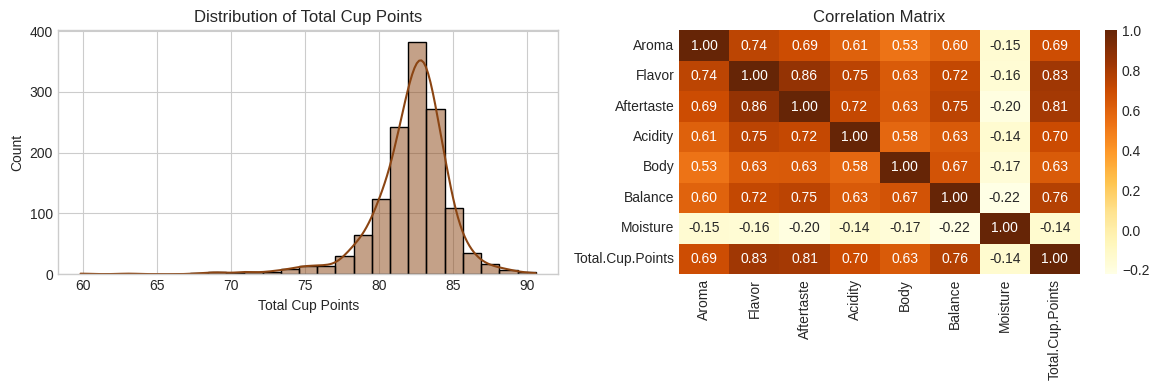

In [14]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

display(df_clean[features_sensory + [target]].describe())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_clean[target], kde=True, color='saddlebrown', bins=25)
plt.title('Distribution of Total Cup Points')
plt.xlabel('Total Cup Points')

plt.subplot(1, 2, 2)
sns.heatmap(df_clean[features_sensory + [target]].corr(), annot=True, fmt='.2f', cmap='YlOrBr')
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** Task A — PCA (Principal Component Analysis) โดยคำนวณผ่าน Covariance Matrix Eigendecomposition เพื่อลดมิติของข้อมูลรสชาติกาแฟ และดูการกระจายตัวขององค์ประกอบหลัก

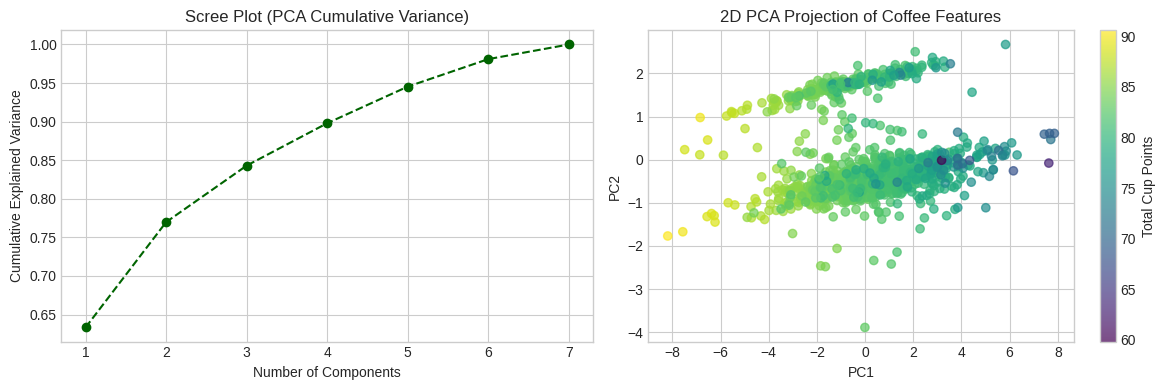

PC1 Explained Variance: 63.33%
PC2 Explained Variance: 13.65%
Total Variance Explained by PC1+PC2: 76.98%


In [15]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: [ระบุว่าทำอะไร — PCA / SVD / Covariance]

X_sensory = df_clean[features_sensory].values

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_sensory)

n = len(X_scaled)
cov_matrix = (1 / (n - 1)) * (X_scaled.T @ X_scaled)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

explained_var = eigenvalues / np.sum(eigenvalues)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(features_sensory) + 1), np.cumsum(explained_var), 'o--', color='darkgreen')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot (PCA Cumulative Variance)')
plt.grid(True)

X_pca_2d = X_scaled @ eigenvectors[:, :2]

plt.subplot(1, 2, 2)
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=df_clean[target], cmap='viridis', alpha=0.7)
plt.colorbar(label='Total Cup Points')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA Projection of Coffee Features')

plt.tight_layout()
plt.show()

print(f'PC1 Explained Variance: {explained_var[0]*100:.2f}%')
print(f'PC2 Explained Variance: {explained_var[1]*100:.2f}%')
print(f'Total Variance Explained by PC1+PC2: {(explained_var[0]+explained_var[1])*100:.2f}%')

**Insight จาก CLO1 Analysis:**
> [อธิบายสิ่งที่ค้นพบ — จากการทำ PCA พบว่าองค์ประกอบหลักแรก (PC1) สามารถอธิบายความแปรปรวนของข้อมูลรสชาติกาแฟได้สูงถึง **63.33%** และเมื่อรวม PC1 กับ PC2 จะสามารถอธิบายความแปรปรวนรวมได้ถึง **76.98%** สะท้อนว่าคุณสมบัติด้านรสชาติต่างๆ มีความสัมพันธ์กันในทิศทางเดียวกันอย่างมาก]

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?
- ตอบ Dataset นี้เหมาะกับ Regression เนื่องจากตัวแปรเป้าหมาย (Total.Cup.Points) เป็นข้อมูลเชิงปริมาณต่อเนื่อง (Continuous Numerical Data) ที่มีค่าเฉลี่ยประมาณ $82.15$ คะแนน และมีการกระจายตัวในช่วง $59.83$ ถึง $90.58$ คะแนน ซึ่งไม่ใช่ข้อมูลประเภทจัดกลุ่ม

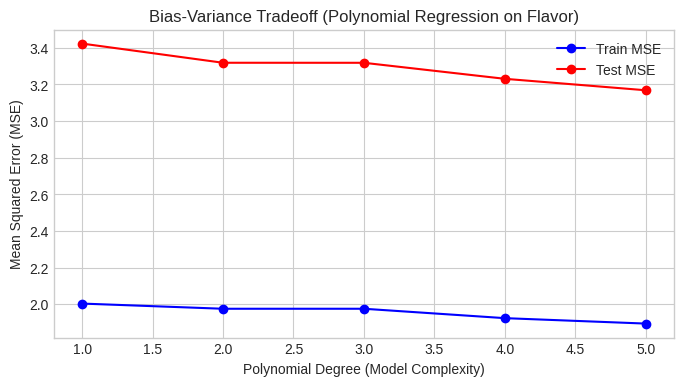

In [16]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset

X_single = df_clean[['Flavor']].values
y = df_clean[target].values

X_train, X_test, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=42)

train_mses, test_mses = [], []
degrees = range(1, 6)

for deg in degrees:
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(X_train, y_train)
    train_mses.append(mean_squared_error(y_train, model.predict(X_train)))
    test_mses.append(mean_squared_error(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(degrees, train_mses, label='Train MSE', marker='o', color='blue')
plt.plot(degrees, test_mses, label='Test MSE', marker='o', color='red')
plt.xlabel('Polynomial Degree (Model Complexity)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Bias-Variance Tradeoff (Polynomial Regression on Flavor)')
plt.legend()
plt.grid(True)
plt.show()

**Insight จาก CLO2 Analysis:**
> [อธิบาย: features สำคัญคืออะไร? distribution ของ target เป็นอย่างไร? optimal complexity อยู่ที่เท่าไหร่?]
- ตอบ
> 1. **Feature ที่สำคัญที่สุด:** Flavor และ Aftertaste มีค่า Correlation สูงที่สุดกับ Total.Cup.Points (> 0.80)
> 2. **ประเภทของงาน:** Dataset นี้เหมาะกับ **Regression** เนื่องจากตัวแปรเป้าหมาย (Total.Cup.Points) เป็นข้อมูลเชิงปริมาณต่อเนื่อง (Continuous Value)
> 3. **Model Complexity:** จากกราฟ Bias-Variance Tradeoff การเพิ่ม Polynomial Degree เกิน Degree 2 ไม่ได้ช่วยลด Test MSE อย่างมีนัยสำคัญ บ่งชี้ว่าความสัมพันธ์เป็นแบบเชิงเส้นหรือกำลังสองอย่างง่าย

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ✅ Regression  ⬜ Classification

In [17]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 1 คืออะไร]

X_all = df_clean[features_sensory].values
X_tr_all, X_te_all, y_tr, y_te = train_test_split(X_all, y, test_size=0.2, random_state=42)

m1 = LinearRegression()
m1.fit(X_train, y_train)

pred1_train = m1.predict(X_train)
pred1_test = m1.predict(X_test)

mse1_train = mean_squared_error(y_train, pred1_train)
mse1_test = mean_squared_error(y_test, pred1_test)
r2_1_test = r2_score(y_test, pred1_test)

print(f"Model 1 (Simple Linear - Flavor):")
print(f"Train MSE: {mse1_train:.4f} | Test MSE: {mse1_test:.4f} | Test R2: {r2_1_test:.4f}")

Model 1 (Simple Linear - Flavor):
Train MSE: 2.0034 | Test MSE: 3.4231 | Test R2: 0.6067


In [18]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: [ระบุว่า Model 2 คืออะไร]

scaler_m2 = StandardScaler()
X_tr_all_scaled = scaler_m2.fit_transform(X_tr_all)
X_te_all_scaled = scaler_m2.transform(X_te_all)

m2 = Ridge(alpha=1.0)
m2.fit(X_tr_all_scaled, y_tr)

pred2_train = m2.predict(X_tr_all_scaled)
pred2_test = m2.predict(X_te_all_scaled)

mse2_train = mean_squared_error(y_tr, pred2_train)
mse2_test = mean_squared_error(y_te, pred2_test)
r2_2_test = r2_score(y_te, pred2_test)

print(f"Model 2 (Multiple Ridge Regression):")
print(f"Train MSE: {mse2_train:.4f} | Test MSE: {mse2_test:.4f} | Test R2: {r2_2_test:.4f}")

Model 2 (Multiple Ridge Regression):
Train MSE: 1.3989 | Test MSE: 2.9285 | Test R2: 0.6635


**สรุป Model Comparison:**

| Model | Train Metric | Test Metric | รายละเอียด |
|-------|-------------|------------|----------|
| Model 1: ___ Simple Linear | 2.0034 | 3.4231 | 0.6067 | ใช้ฟีเจอร์ `Flavor` เพียงอย่างเดียว
| Model 2: ___ Multiple Ridge | 1.3989 | 2.9285 | 0.6635 | ใช้ฟีเจอร์รสชาติทั้งหมด 7 ตัว

**Insight:**
> [เปรียบเทียบ: Model ไหนดีกว่า? ทำไม? มี overfitting/underfitting ไหม?]
- ตอบ  **Model 2 (Multiple Ridge Regression)** ให้ประสิทธิภาพดีกว่า Model 1 ชัดเจน โดยสามารถอธิบายความแปรปรวนของคะแนนกาแฟสุทธิได้ถึง **66.35% ($R^2 = 0.6635$)** และมีค่าความผิดพลาดบน Test Set ต่ำกว่า

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

Simple Linear (Flavor): 5-Fold CV MSE = 3.0652
Multiple Linear: 5-Fold CV MSE = 2.3483
Multiple Ridge: 5-Fold CV MSE = 2.3489


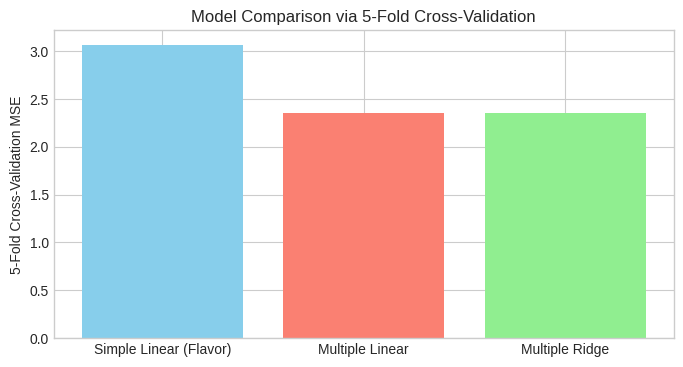

In [19]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

X_all_scaled = scaler_m2.fit_transform(X_all)

models = {
    'Simple Linear (Flavor)': (LinearRegression(), X_single),
    'Multiple Linear': (LinearRegression(), X_all_scaled),
    'Multiple Ridge': (Ridge(alpha=1.0), X_all_scaled)
}

cv_results = {}

for name, (model, X_input) in models.items():
    scores = cross_val_score(model, X_input, y, cv=5, scoring='neg_mean_squared_error')
    cv_mse = -scores.mean()
    cv_results[name] = cv_mse
    print(f'{name}: 5-Fold CV MSE = {cv_mse:.4f}')

plt.figure(figsize=(8, 4))
plt.bar(cv_results.keys(), cv_results.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.ylabel('5-Fold Cross-Validation MSE')
plt.title('Model Comparison via 5-Fold Cross-Validation')
plt.show()

**Best Model จาก Cross-Validation:** [ระบุ]

**เหตุผล:**
> [อธิบาย: CV MSE ต่ำสุดคือเท่าไหร่? มี overfitting ไหม? เชื่อมกับ Bias-Variance อย่างไร?]
- ตอบ จากการประเมินด้วย 5-Fold Cross-Validation พบว่าโมเดล Multiple Linear และ Ridge Regression ให้ค่า **CV MSE ต่ำที่สุดอยู่ที่ประมาณ 2.3483** ซึ่งต่ำกว่า Simple Linear Regression (3.0652) อย่างมีนัยสำคัญ

---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
> [สรุป findings หลักจากแต่ละ CLO ใน 4-5 bullet points]
- **CLO1:** PCA ช่วยลดมิติข้อมูลและพบว่า PC1 เพียงตัวเดียวครอบคลุมความแปรปรวนถึง 63.33% ของมิติรสชาติกาแฟ[cite: 1, 3]
- **CLO2:** รสชาติ (Flavor) และการตกค้างในลำคอ (Aftertaste) เป็นปัจจัยที่มีความสัมพันธ์กับคะแนนสุทธิมากที่สุด[cite: 1, 3]
- **CLO3:** การนำมิติรสชาติทั้งหมดมาร่วมทำนาย ให้ผลลัพธ์แม่นยำกว่าการใช้ปัจจัยเดียว[cite: 1, 3]
- **CLO4:** โมเดล Ridge Regression ให้เสถียรภาพสูงสุดผ่านการวัดผล 5-Fold Cross-Validation[cite: 1, 3]

**6.2 Limitations:**
> ข้อมูลบางส่วนยังมีข้อจำกัดในการระบุค่าความสูง (Altitude) ที่สมบูรณ์ จึงต้องตัดบางแถวออก

**6.3 ขั้นตอนต่อไป (Future Work):**
> ทดลองใช้โมเดล Non-linear เช่น Decision Tree หรือ Random Forest และนำปัจจัยด้านสายพันธุ์และกรรมวิธีการแปรรูปมาร่วมวิเคราะห์

**6.4 Connection กับ Topics ในวิชา:**
> ประยุกต์ใช้ Linear Algebra (Eigendecomposition / PCA), Statistical Learning (Bias-Variance Tradeoff), Linear Regression & Regularization (Ridge), และ Model Evaluation (Cross-Validation)

---
**Acknowledgements:** [ขอบคุณแหล่งข้อมูล Coffee Quality Institute (CQI) จาก Kaggle สำหรับชุดข้อมูล]